# Hybrid Quantum-Classical Reinforcement Learning Experiments

___
___

## Introduction
___

This set of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

This notebook will present:
1. Two RL environments
2. AutoEncoders for dimensionality reduction
3. Classical PPO agents
4. Qubit-based PPO agents
5. Photonic-based PPO agents
6. The results of the different agents on the two environments
7. Conclusions and follow-ups


In [1]:
# Install / import the necessary libraries
!pip install torch gymnasium swig "gymnasium[box2d]"
import time
import random
from collections import namedtuple, deque
from itertools import count
from IPython.display import display, clear_output
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym

seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

## 1 - RL Environments: Cart Pole and Lunar Lander
___

In the article, the authors use two environments: CartPole-v1 (OpenAI Gym) and Maze-v0 (custom environment). For this experiment to run in required time, we will use Cart Pole and Lunar Lander from OpenAI Gym.

But first, a small refresher on Reinforcement Learning: in this sub-field of Machine Learning, an agent interacts with an environment and learns a Policy.

<div align="center">
<img src="images/qrl_demo_rl.png" width="800"/>
</div>

At each moment, the state of the environment is observed and the agent chooses an action accordingly. This action changes the environment, which gives a reward (depending on how good that action was for the overall objective) and the new state. The agent must learn to choose the best actions depending on the environment's state, in order to maximize the cumulative reward.

### Cart Pole

<div align="center">
<img src="images/qrl_demo_cartpole.gif" width="300"/>
</div>

In this Classic Control environment, the agent must learn to balance a pole on top of a cart by moving the cart left and right. 

At each step, the agent receives 4 observations: the cart's position, its velocity, the pole's angle and the pole's angular velocity. From these observations, it must then choose between 2 actions: push the cart to the left or push the cart to the right.

The agent receives a +1 reward for each step where the pole is considered balanced (pole's angle greater than ±12°). The simulation (episode) ends when the pole is no longer balanced, when the cart's position is getting out of display or when the episode is > 500 steps.

More details about this environment can be found here: https://gymnasium.farama.org/environments/classic_control/cart_pole/.

In [2]:
# Create the Cart Pole environment
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)

42

### Lunar Lander

<div align="center">
<img src="images/qrl_demo_lunarlander.gif" width="300"/>
</div>

In this Box2D environment, the agent learns to land a spaceship in a designated area. 

At each step, the agent gets 8 observations: the x and y coordinates of the ship, its x and y linear velocities, its angle, angular velocity, and whether each leg of the ship is touching the ground. The agent can choose between 4 actions: do nothing, fire the main engine, fire the left engine or fire the right one.

A reward is granted at each step, depending on the ship's position compared to the landing pad, its velocity, orientation, engine firings and contact with the ground. An additional reward is given at the end depending on whether the ship landed correctly or not. The episode ends when the ship crashes, is getting out of display or stalls.

More information about this environment can be found here: https://gymnasium.farama.org/environments/box2d/lunar_lander/.

In [3]:
lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)

42

## 2 - AutoEncoders (AEs)
___

The Cart Pole and Lunar Lander environments contain 4 and 8 observations respectively. Both can be reduced to only 2 variables with an AE.

AEs are used for dimensionality reduction, data compression and feature learning. They are composed of an encoder which produces a compressed representation of the original data, and a decoder which reconstructs the original data from the compressed, latent space representation.

<div align="center">
<img src="images/qrl_demo_autoencoder.png" width="800"/>
</div>

As such, AEs learn to create a relevant low-dimensional latent space representation of the original data. This is useful for quantum computing as it reduces the amount of data nodes (qubits/qumodes) needed and therefore computational cost.

Though AEs are usually trained in an unsupervised manner, learning to reconstruct the original data by themselves, the article's approach is different. Here, the authors choose to train the AE jointly with the PPO agents. This ensures that the latent space representation learned by the AE is specifically suited to the RL problem.

In [4]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, encoded_dim):
        super(AutoEncoder, self).__init__()
        self.encoder_layer1 = nn.Linear(input_dim, hidden_dim)
        self.encoder_layer2 = nn.Linear(hidden_dim, encoded_dim)

        # self.decoder_layer1 = nn.Linear(encoded_dim, hidden_dim)
        # self.decoder_layer2 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x = self.encoder_layer1(x)
        x = F.relu(x)
        x = self.encoder_layer2(x)
        z = F.sigmoid(x)

        # x = self.decoder_layer1(z)
        # x = F.relu(x)
        # x_hat = self.decoder_layer2(x)
        return z#, x_hat

## 3 - Classical PPO
___

The classical framework of Proximal Policy Optimization involves two neural networks: the Actor and the Critic. At each step, the Actor receives the compressed observations of the environment from the AE (state), and outputs a probability distribution over the possible actions. An action is sampled from this distribution and executed in the environment. 

The environment gives a reward for each action taken. The goal of PPO is again to maximize the overall cumulative reward at each episode. 

To do so, the Critic learns to associate each state with a value, representing the expected reward from this state. Therefore, the Critic needs to learn the expected reward of each state and the Actor needs to assign for each state a higher probability to actions that will give better rewards.

<div align="center">
<img src="images/qrl_demo_classicalPPO.png" width="800"/>
</div>

To correlate the two, an advantage function is calculated. It measures the amount by which the cumulative reward based on the policy executed by the Actor exceeds the expected reward predicted by the Critic.

This advantage function updates the Critic: it learns from the Actor's experience what actual rewards were given by the environment.

The advantage function also serves to update the Actor: based on its result, a new version of the Actor's policy is created. Then, the Actor's policy is updated by mixing its former policy with the new one. This loss calculation also ensures that the updates are smooth and do not take too big of a step. The loss calculated is called the clipped surrogate objective, and it is the landmark of PPO. The updates are made via backpropagation.

Finally, a Replay Buffer is used to store { s(t), a(t), r(t), s(t+1) }, so that the Critic can sample from it in batches.

In [5]:
Experience = namedtuple(
    'Experience',
    ('encoded_state', 'reconstructed_state', 'action', 'action_log_probability', 'trajectory_reward', 'advantage')
    )

class ReplayBuffer:
    def __init__(self, size):
        self.memory = deque([], maxlen=size)

    def add(self, *args):
        self.memory.append(Experience(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)
    
class BasicNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.layer3(x)
        x = F.relu(x)
        x = self.dropout(x)
        return self.layer4(x)

class ClassicalPPO:
    def __init__(self, n_observations, latent_dim, n_actions, actor_hidden_dim, critic_hidden_dim):
        self.actor = BasicNN(input_dim=latent_dim, hidden_dim=actor_hidden_dim, output_dim=n_actions).to(device)
        self.critic = BasicNN(input_dim=n_observations, hidden_dim=critic_hidden_dim, output_dim=1).to(device)

    def select_action(self, encoded_state):
        actions_preds = self.actor(encoded_state)
        action_probs = F.softmax(actions_preds, dim=-1)
        actions_distribution = torch.distributions.Categorical(action_probs)
        action = actions_distribution.sample()
        action_log_probability = actions_distribution.log_prob(action)
        return action, action_log_probability
    
    def optimize_models(self, parameters, replay, policy_optimizer, value_optimizer):
        experiences = replay.sample(parameters["batch_size"])
        batch = Experience(*zip(*experiences))
        encoded_states = torch.cat(batch.encoded_state)
        reconstructed_states = torch.cat(batch.reconstructed_state)
        actions = torch.cat(batch.action)
        action_log_probabilities = torch.cat(batch.action_log_probability)
        trajectory_rewards = torch.cat(batch.trajectory_reward)
        advantages = torch.cat(batch.advantage)
        
        new_actions_preds = self.actor(encoded_states)
        new_action_probs = F.softmax(new_actions_preds, dim=-1)
        new_actions_distribution = torch.distributions.Categorical(new_action_probs)
        new_actions_log_probabilities = new_actions_distribution.log_prob(actions)

        new_state_values = self.critic(reconstructed_states)
        entropy = new_actions_distribution.entropy()

        advantages = advantages.detach()
        policy_ratio = torch.exp(new_actions_log_probabilities - action_log_probabilities)
        objective = policy_ratio * advantages
        clipped_objective = torch.clamp(policy_ratio, min=1.0-parameters["epsilon"], max=1.0+parameters["epsilon"]) * advantages
        clipped_surrogate_loss = torch.min(objective, clipped_objective)

        policy_loss = - (clipped_surrogate_loss + parameters["entropy_coeff"]*entropy).sum()
        value_loss = F.mse_loss(trajectory_rewards, new_state_values).sum()
        
        policy_optimizer.zero_grad()
        policy_loss.backward(retain_graph=True)
        policy_optimizer.step()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

## 4 - Qubit-based PPO
___


## 5 - Photonic-based PPO
___

Continuous variable
Linear only

## 6 - Results
___

In [ ]:
def show_env(env):
    frame = env.render()
    clear_output(wait=True)
    display(Image.fromarray(frame))
    time.sleep(0.02)

def run(PPOClass, env, parameters, display_env=False):
    n_observations = env.observation_space.shape[0]
    n_actions = env.action_space.n
    replay = ReplayBuffer(500)
    ae = AutoEncoder(n_observations, parameters["ae_hidden_dim"], parameters["ae_output_dim"]).to(device)
    ppo = PPOClass(n_observations, parameters["ae_output_dim"], n_actions, parameters["actor_hidden_dim"], parameters["critic_hidden_dim"])
    policy_optimizer = optim.Adam(list(ae.parameters()) + list(ppo.actor.parameters()), lr=0.0002)
    value_optimizer = optim.Adam(ppo.critic.parameters(), lr=0.0002)

    rewards = []
    for i in range(parameters["n_episodes"]):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0).to(device)
        encoded_state = ae(state)
        cumulative_rewards = []
        for t in count():
            if display_env:
                show_env(env)
            with torch.no_grad():
                action, action_log_probability = ppo.select_action(encoded_state)
                state_value = ppo.critic(state)

            observation, reward, terminated, truncated, _ = env.step(action.item())
            cumulative_rewards.append(reward)
            done = terminated or truncated

            if terminated:
                next_state = None
                trajectory_reward = torch.zeros(1, dtype=torch.float32, device=device).unsqueeze(0).to(device)
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0).to(device)
                with torch.no_grad():
                    next_value = ppo.critic(next_state)
                trajectory_reward = reward + parameters["gamma"] * next_value

            advantage = trajectory_reward - state_value

            replay.add(encoded_state.detach(), state.detach(), action, action_log_probability, trajectory_reward, advantage)

            if len(replay) >= parameters["batch_size"]:
                ppo.optimize_models(parameters, replay, policy_optimizer, value_optimizer)

            if done:
                rewards.append(sum(cumulative_rewards))
                break

            state = next_state
            encoded_state = ae(state)
            
    return rewards

def plot_results(rewards):
    plt.figure()
    plt.plot(rewards)
    plt.xlabel("Episodes")
    plt.ylabel("Cumulative reward")
    plt.show()

# Set the parameters
common_parameters = { 
    "ae_hidden_dim": 4, "ae_output_dim": 2, "actor_hidden_dim": 16, "critic_hidden_dim": 16, 
    "batch_size": 32, "n_episodes": 5000,
    "gamma": 0.99, "epsilon": 0.2, "entropy_coeff": 0.001
    }

### On Cart Pole

In [7]:
# 1. Classical PPO
classical_rewards = run(ClassicalPPO, cartpole_env, common_parameters)

In [8]:
# 2. Qubit PPO

In [9]:
# 3. Photonic PPO

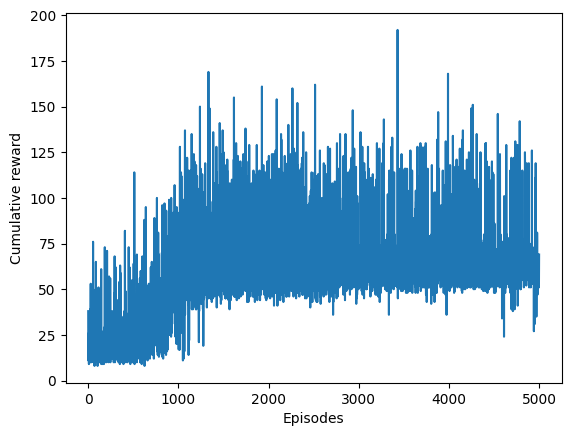

In [10]:
plot_results(classical_rewards)

### On Lunar Lander

In [11]:
# 1. Classical PPO
classical_rewards = run(ClassicalPPO, lunarlander_env, common_parameters)

KeyboardInterrupt: 

In [ ]:
# 2. Qubit PPO

In [ ]:
# 3. Photonic PPO

In [ ]:
plot_results(classical_rewards)

## 7 - Conclusions and follow-ups
___

Environment 3: Maze or Car Racing (Not doable in required time)

Photonic PPO (Non linear with deprecated SF or Piquasso)